In [4]:
# =================================================================
# CELLA 1 (NOTEBOOK 5): CARICAMENTO, RESHAPE E NORMALIZZAZIONE
# =================================================================
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("📥 Caricamento dati dal file .npz...")
dati_salvati = np.load('dataset_elaborato.npz')
X_numpy = dati_salvati['X_768']
y_numpy = dati_salvati['Y'].reshape(-1, 1) # Lo mettiamo in colonna

# 1. NORMALIZZAZIONE DEI PUNTEGGI (Fondamentale!)
# Questo trasforma i tuoi 1500, -300 ecc. in piccoli numeri centrati sullo zero
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y_numpy)
print(f"✅ Punteggi normalizzati. Media: {y_scaled.mean():.2f}, DevStd: {y_scaled.std():.2f}")

# 2. Convertiamo in Tensori PyTorch
X_tensor_1d = torch.tensor(X_numpy, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# 3. Reshape 3D
X_tensor_3d = X_tensor_1d.view(-1, 12, 8, 8)

# 4. Split
X_train, X_val, y_train, y_val = train_test_split(X_tensor_3d, y_tensor, test_size=0.1, random_state=42)

print(f"\n✅ Dati pronti! Forma X: {X_train.shape}")

📥 Caricamento dati dal file .npz...
✅ Punteggi normalizzati. Media: -0.00, DevStd: 1.00

✅ Dati pronti! Forma X: torch.Size([303212, 12, 8, 8])


In [5]:
# =================================================================
# CELLA 2: ARCHITETTURA IBRIDA RESIDUAL (Il bypass lineare)
# =================================================================
import torch.nn as nn
import torch.nn.functional as F

class MotoreScacchi_Residuale(nn.Module):
    def __init__(self):
        super(MotoreScacchi_Residuale, self).__init__()
        
        # 1. IL PERCORSO CONVOLUZIONALE (I dettagli tattici)
        self.conv1 = nn.Conv2d(12, 16, kernel_size=3, padding=1)
        self.fc_cnn = nn.Linear(16 * 8 * 8, 1)
        
        # 2. L'AUTOSTRADA LINEARE (Il "Modello 1" integrato)
        # 12 canali * 8 * 8 = 768 input esatti
        self.percorso_lineare = nn.Linear(768, 1)

    def forward(self, x):
        # x entra come (Batch, 12, 8, 8)
        
        # --- Calcolo percorso Lineare (Matematica pura e diretta) ---
        x_flat = x.view(x.size(0), -1)  # Appiattisce in 768
        output_lineare = self.percorso_lineare(x_flat)
        
        # --- Calcolo percorso Convoluzionale ---
        c = F.relu(self.conv1(x))
        c_flat = c.view(c.size(0), -1)
        output_cnn = self.fc_cnn(c_flat)
        
        # --- LA SOMMA MATEMATICA ---
        # La rete è matematicamente costretta a imparare almeno quanto il Modello 1
        return output_lineare + output_cnn

modello_cnn = MotoreScacchi_Residuale()
print("✅ Architettura Residuale pronta: Gradienti sbloccati tramite autostrada lineare.")

✅ Architettura Residuale pronta: Gradienti sbloccati tramite autostrada lineare.


In [6]:
# =================================================================
# CELLA 3: ADDESTRAMENTO CON FIX DIMENSIONALE E TIMER
# =================================================================
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Creazione dei lotti da 256 scacchiere
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)

criterio = nn.HuberLoss(delta=1.0)
# Riportiamo il Learning Rate a un valore brillante
ottimizzatore = optim.Adam(modello_cnn.parameters(), lr=0.001)

EPOCHE = 50
print(f"🚀 Inizio addestramento con FIX dimensionale per {EPOCHE} epoche...\n")

for epoca in range(EPOCHE):
    inizio_epoca = time.time()  # Partenza cronometro
    
    # --- FASE DI ADDESTRAMENTO ---
    modello_cnn.train()
    loss_train_tot = 0.0
    for batch_X, batch_y in train_loader:
        ottimizzatore.zero_grad()
        prev = modello_cnn(batch_X)
        
        # ⚠️ IL FIX CRITICO: Forza entrambe le variabili ad essere vettori piatti [Batch]
        # Questo impedisce a PyTorch di fare "broadcasting" e incrociare i dati sbagliati
        loss = criterio(prev.view(-1), batch_y.view(-1)) 
        
        loss.backward()
        ottimizzatore.step()
        loss_train_tot += loss.item()
        
    # --- FASE DI VALIDAZIONE ---
    modello_cnn.eval()
    loss_val_tot = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            prev = modello_cnn(batch_X)
            
            # Applichiamo lo stesso lucchetto dimensionale qui
            loss = criterio(prev.view(-1), batch_y.view(-1))
            loss_val_tot += loss.item()
            
    # Calcolo medie
    l_train = loss_train_tot / len(train_loader)
    l_val = loss_val_tot / len(val_loader)
    
    fine_epoca = time.time()  # Fine cronometro
    tempo_impiegato = fine_epoca - inizio_epoca 
    
    print(f"Epoca [{epoca+1:02d}/{EPOCHE}] | Loss Train: {l_train:.4f} | Loss Val: {l_val:.4f} | Tempo: {tempo_impiegato:.1f}s")

torch.save(modello_cnn.state_dict(), 'modello_cnn_ibrida_pesi.pth')
print("\n✅ Addestramento completato. Pesi salvati!")

🚀 Inizio addestramento con FIX dimensionale per 50 epoche...

Epoca [01/50] | Loss Train: 0.2004 | Loss Val: 0.1992 | Tempo: 11.9s
Epoca [02/50] | Loss Train: 0.2000 | Loss Val: 0.1990 | Tempo: 11.2s
Epoca [03/50] | Loss Train: 0.1994 | Loss Val: 0.1984 | Tempo: 12.4s
Epoca [04/50] | Loss Train: 0.1988 | Loss Val: 0.1978 | Tempo: 11.1s
Epoca [05/50] | Loss Train: 0.1980 | Loss Val: 0.1969 | Tempo: 11.4s
Epoca [06/50] | Loss Train: 0.1970 | Loss Val: 0.1961 | Tempo: 12.6s
Epoca [07/50] | Loss Train: 0.1962 | Loss Val: 0.1962 | Tempo: 12.5s
Epoca [08/50] | Loss Train: 0.1956 | Loss Val: 0.1953 | Tempo: 16.4s
Epoca [09/50] | Loss Train: 0.1951 | Loss Val: 0.1951 | Tempo: 12.4s
Epoca [10/50] | Loss Train: 0.1947 | Loss Val: 0.1950 | Tempo: 15.7s
Epoca [11/50] | Loss Train: 0.1944 | Loss Val: 0.1949 | Tempo: 13.6s
Epoca [12/50] | Loss Train: 0.1941 | Loss Val: 0.1948 | Tempo: 13.1s
Epoca [13/50] | Loss Train: 0.1938 | Loss Val: 0.1948 | Tempo: 11.5s
Epoca [14/50] | Loss Train: 0.1936 | Loss

In [4]:
# =================================================================
# CELLA EXTRA: IL TEST DELLA VERITÀ (Sanity Check con Modello 1)
# =================================================================
import torch
import torch.nn as nn
import torch.optim as optim

print("🕵️ Avvio del Sanity Check: Usiamo la vecchia architettura sui nuovi dati...")

# Ricreiamo ESATTAMENTE il Modello 1 che funzionava nel Notebook 2
class Modello1_Test(nn.Module):
    def __init__(self):
        super(Modello1_Test, self).__init__()
        self.fc1 = nn.Linear(768, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        # Prende il cubo 3D (12, 8, 8) e lo schiaccia in 768 per forza
        x = x.view(x.size(0), -1) 
        x = self.relu(self.fc1(x))
        return self.fc2(x)

modello_test = Modello1_Test()
criterio_test = nn.HuberLoss(delta=1.0)
ottimizzatore_test = optim.Adam(modello_test.parameters(), lr=0.001)

# Addestramento lampo di sole 3 epoche
for epoca in range(3):
    modello_test.train()
    loss_tot = 0.0
    for batch_X, batch_y in train_loader:
        ottimizzatore_test.zero_grad()
        prev = modello_test(batch_X)
        loss = criterio_test(prev.view(-1), batch_y.view(-1))
        loss.backward()
        ottimizzatore_test.step()
        loss_tot += loss.item()
        
    print(f"Test Epoca {epoca+1}/3 | Loss Train: {(loss_tot/len(train_loader)):.4f}")

print("Risultato: Se la Loss è rimasta a 2.7, i dati sono rotti. Se è crollata (es. sotto 1.5), la CNN è il problema.")

🕵️ Avvio del Sanity Check: Usiamo la vecchia architettura sui nuovi dati...
Test Epoca 1/3 | Loss Train: 0.2000
Test Epoca 2/3 | Loss Train: 0.1999
Test Epoca 3/3 | Loss Train: 0.1999
Risultato: Se la Loss è rimasta a 2.7, i dati sono rotti. Se è crollata (es. sotto 1.5), la CNN è il problema.


In [5]:
# =================================================================
# CELLA 4: MOTORE DECISIONALE (BEAM SEARCH)
# =================================================================
import chess.svg
from IPython.display import display, SVG

CONFIG_PROFONDITA = 4  
CONFIG_BEAM_K     = 5  

def valutazione_minimax(board, depth, alpha, beta, is_maximizing, valuta_func):
    if depth == 0 or board.is_game_over(): return valuta_func(board)
    
    if is_maximizing:
        max_eval = -float('inf')
        for move in board.legal_moves:
            board.push(move)
            ev = valutazione_minimax(board, depth - 1, alpha, beta, False, valuta_func)
            board.pop()
            max_eval = max(max_eval, ev); alpha = max(alpha, ev)
            if beta <= alpha: break
        return max_eval
    else:
        min_eval = float('inf')
        for move in board.legal_moves:
            board.push(move)
            ev = valutazione_minimax(board, depth - 1, alpha, beta, True, valuta_func)
            board.pop()
            min_eval = min(min_eval, ev); beta = min(beta, ev)
            if beta <= alpha: break
        return min_eval

def ricerca_mossa_cnn(board, valuta_func):
    mosse_valutate = []
    is_maximizing = board.turn == chess.WHITE
    
    for move in board.legal_moves:
        board.push(move); p_base = valuta_func(board); board.pop()
        mosse_valutate.append((p_base, move))
    
    mosse_valutate.sort(key=lambda x: x[0], reverse=is_maximizing)
    beam = mosse_valutate[:CONFIG_BEAM_K]
    
    mossa_ottimale = beam[0][1]
    v_best = -float('inf') if is_maximizing else float('inf')
    
    for _, move in beam:
        board.push(move)
        voto = valutazione_minimax(board, CONFIG_PROFONDITA - 1, -float('inf'), float('inf'), not is_maximizing, valuta_func)
        board.pop()
        
        if is_maximizing and voto > v_best:
            v_best = voto; mossa_ottimale = move
        elif not is_maximizing and voto < v_best:
            v_best = voto; mossa_ottimale = move
                
    return mossa_ottimale

print(f"✅ Motore configurato (Profondità {CONFIG_PROFONDITA}, Beam {CONFIG_BEAM_K})")

✅ Motore configurato (Profondità 4, Beam 5)


--- BENCHMARK MODELLO 3 (CNN) ---
Puzzle 1: Matto in 1 (Barbiere) -> ✅ PASS [1.24s]


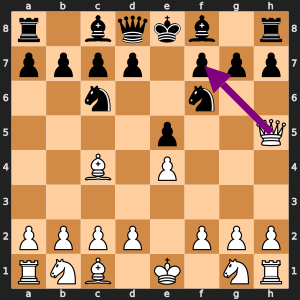

--------------------------------------------------
Puzzle 2: Guadagno di materiale (Forchetta) -> ❌ FAIL (giocata e2a6) [16.18s]


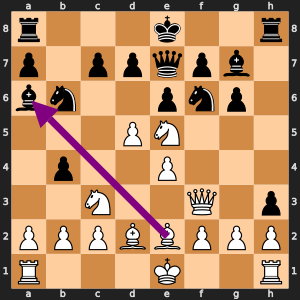

--------------------------------------------------
Puzzle 3: Matto in 1 (Torre in traversa) -> ✅ PASS [0.92s]


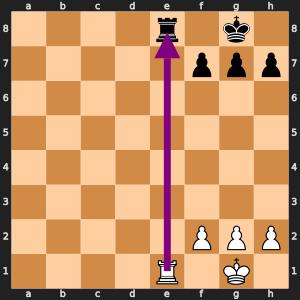

--------------------------------------------------
Puzzle 4: Inchiodatura del Cavallo -> ❌ FAIL (giocata c4f7) [3.53s]


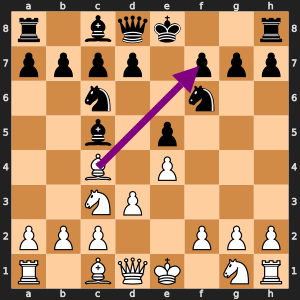

--------------------------------------------------
Puzzle 5: Finale di Re (Avvicinamento tattico) -> ✅ PASS [0.00s]


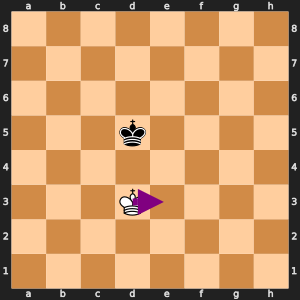

--------------------------------------------------
RISULTATO FINALE CNN: 3/5


In [6]:
# =================================================================
# CELLA 5: BENCHMARK TATTICO (Solo CNN)
# =================================================================
import time

def valuta_cnn(board):
    matrice = np.zeros((12, 8, 8), dtype=np.float32)
    for sq in chess.SQUARES:
        pz = board.piece_at(sq)
        if pz:
            c = (pz.piece_type - 1) + (0 if pz.color == chess.WHITE else 6)
            matrice[c, chess.square_rank(sq), chess.square_file(sq)] = 1.0
            
    tensor = torch.tensor(matrice).unsqueeze(0) 
    modello_cnn.eval()
    with torch.no_grad():
        voto = modello_cnn(tensor).item()
    return voto if board.turn == chess.WHITE else -voto

puzzles = [
    ("r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4", "h5f7", "Matto in 1 (Barbiere)"),
    ("r3k2r/p1ppqpb1/bn2pnp1/3PN3/1p2P3/2N2Q1p/PPPBBPPP/R3K2R w KQkq - 0 1", "e5d7", "Guadagno di materiale (Forchetta)"),
    ("4r1k1/5ppp/8/8/8/8/5PPP/4R1K1 w - - 0 1", "e1e8", "Matto in 1 (Torre in traversa)"),
    ("r1bqk2r/pppp1ppp/2n2n2/2b1p3/2B1P3/2NP4/PPP2PPP/R1BQK1NR w KQkq - 1 5", "c1g5", "Inchiodatura del Cavallo"),
    ("8/8/8/3k4/8/3K4/8/8 w - - 0 1", "d3e3", "Finale di Re (Avvicinamento tattico)")
]

print("--- BENCHMARK MODELLO 3 (CNN) ---")
punti = 0

for i, (fen, target, desc) in enumerate(puzzles):
    board = chess.Board(fen)
    t0 = time.time()
    mossa = ricerca_mossa_cnn(board, valuta_cnn) 
    t1 = time.time() - t0
    
    esito = "✅ PASS" if str(mossa) == target else f"❌ FAIL (giocata {mossa})"
    if str(mossa) == target: punti += 1
    
    print(f"Puzzle {i+1}: {desc} -> {esito} [{t1:.2f}s]")
    
    freccia = [chess.svg.Arrow(mossa.from_square, mossa.to_square, color="purple")]
    display(SVG(chess.svg.board(board, arrows=freccia, size=300)))
    print("-" * 50)

print(f"RISULTATO FINALE CNN: {punti}/5")

In [6]:
# --- 0. IMPORTAZIONI FONDAMENTALI ---
import pandas as pd
import chess
import torch
import numpy as np
from tqdm import tqdm

# --- 1. FUNZIONI DI TRASFORMAZIONE ---
def board_to_3d(board):
    canali_pezzi = {'P':0, 'N':1, 'B':2, 'R':3, 'Q':4, 'K':5, 'p':6, 'n':7, 'b':8, 'r':9, 'q':10, 'k':11}
    tensor_3d = np.zeros((12, 8, 8), dtype=np.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            channel = canali_pezzi[piece.symbol()]
            row, col = divmod(square, 8)
            tensor_3d[channel, row, col] = 1.0
    return torch.tensor(tensor_3d).unsqueeze(0)

# --- 2. LOGICA DELLA SFIDA (FILTRATA PER MATTO IN 1) ---
def test_puzzles(csv_path, modelli_dict, n_puzzles=None):
    print(f"🔍 Ricerca dei puzzle 'Matto in 1' nel file {csv_path}...")
    
    chunk_size = 100000  # Legge 100.000 righe alla volta per non saturare la RAM
    puzzle_filtrati = []
    totale_trovati = 0
    
    # Leggiamo il file a pezzi
    for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
        # Evitiamo errori se ci sono righe senza temi
        chunk['Themes'] = chunk['Themes'].fillna('')
        
        # Filtriamo solo quelli che contengono 'mateIn1' nei Temi
        matto_in_1 = chunk[chunk['Themes'].str.contains('mateIn1')]
        puzzle_filtrati.append(matto_in_1)
        totale_trovati += len(matto_in_1)
        
        # Se abbiamo un limite e lo abbiamo raggiunto, ci fermiamo
        if n_puzzles is not None and totale_trovati >= n_puzzles:
            break
            
    # Uniamo tutti i puzzle trovati in un unico DataFrame
    df = pd.concat(puzzle_filtrati, ignore_index=True)
    
    if n_puzzles is not None:
        df = df.head(n_puzzles) # Tagliamo per avere il numero esatto richiesto
        print(f"📊 Estrazione completata: useremo esattamente {n_puzzles} puzzle da 1 mossa!")
    else:
        n_puzzles = len(df)
        print(f"🚀 Hai deciso di analizzarli tutti! Nel file ci sono in totale: {n_puzzles} puzzle 'Matto in 1'!")
    
    # Inizializziamo i punteggi
    punteggi = {nome: 0 for nome in modelli_dict.keys()}
    
    print("⚔️ La sfida è iniziata! I modelli stanno valutando le mosse mortali...")
    
    # tqdm mostra la barra di avanzamento
    for _, row in tqdm(df.iterrows(), total=n_puzzles):
        fen = row['FEN']
        # La mossa corretta è sempre la prima (e in questo caso l'unica che serve)
        mossa_corretta_uci = row['Moves'].split()[0]
        
        board = chess.Board(fen)
        turno_bianco = (board.turn == chess.WHITE)
        mosse_legali = list(board.legal_moves)
        
        for nome_modello, modello in modelli_dict.items():
            modello.eval()
            miglior_mossa = None
            miglior_val = -float('inf') if turno_bianco else float('inf')
            
            with torch.no_grad():
                for mossa in mosse_legali:
                    board.push(mossa)
                    input_tensor = board_to_3d(board)
                    
                    val = modello(input_tensor).item()
                    board.pop()
                    
                    if turno_bianco:
                        if val > miglior_val:
                            miglior_val = val
                            miglior_mossa = mossa
                    else:
                        if val < miglior_val:
                            miglior_val = val
                            miglior_mossa = mossa
            
            # Controllo se il modello ha beccato la mossa di matto
            if miglior_mossa and miglior_mossa.uci() == mossa_corretta_uci:
                punteggi[nome_modello] += 1
                
    # --- 3. RISULTATI FINALI ---
    print("\n" + "="*45)
    print("🏆 RISULTATI DELLA GRANDE SFIDA (MATTO IN 1) 🏆")
    print("="*45)
    for nome, punti in punteggi.items():
        accuracy = (punti / n_puzzles) * 100
        # Spezzata per evitare il famoso SyntaxError
        acc_str = f"{accuracy:.2f}%"
        print(f"| {nome:20} | {punti:4}/{n_puzzles} | Accuratezza: {acc_str:>7} |")
    print("="*45)

# --- 4. ESECUZIONE ---
# Assicurati che i tuoi modelli siano in memoria!
sfidanti = {
    "Lineare (Sanity)": modello_test, 
    "CNN Residuale/Ibrida": modello_cnn
}

# 👇👇👇 MODIFICA QUI IL NUMERO DI PUZZLE 👇👇👇
# Metti un numero (es. 500, 1000) oppure scrivi None (senza virgolette) per farli tutti!
NUMERO_DI_PUZZLE = 100000

test_puzzles('./Data/lichess_puzzle.csv', sfidanti, n_puzzles=NUMERO_DI_PUZZLE)

🔍 Ricerca dei puzzle 'Matto in 1' nel file ./Data/lichess_puzzle.csv...
📊 Estrazione completata: useremo esattamente 100000 puzzle da 1 mossa!
⚔️ La sfida è iniziata! I modelli stanno valutando le mosse mortali...


100%|██████████| 100000/100000 [22:56<00:00, 72.65it/s]  


🏆 RISULTATI DELLA GRANDE SFIDA (MATTO IN 1) 🏆
| Lineare (Sanity)     | 26953/100000 | Accuratezza:  26.95% |
| CNN Residuale/Ibrida | 26785/100000 | Accuratezza:  26.78% |


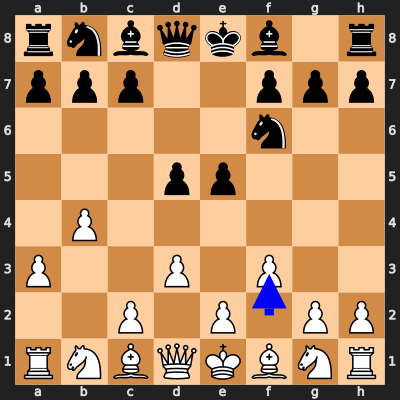

⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).
⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).


In [ ]:
import chess
import chess.svg
import torch
import numpy as np
from IPython.display import display, SVG, clear_output

# --- FUNZIONE DI SUPPORTO: CONVERSIONE BOARD -> TENSOR 3D ---
def board_to_3d_tensor(board):
    # Creiamo il cubo 12x8x8 pieno di zeri
    canali_pezzi = {'P':0, 'N':1, 'B':2, 'R':3, 'Q':4, 'K':5,
                    'p':6, 'n':7, 'b':8, 'r':9, 'q':10, 'k':11}
    tensor_3d = np.zeros((12, 8, 8), dtype=np.float32)
    
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            color_offset = 0 if piece.color == chess.WHITE else 6
            channel = canali_pezzi[piece.symbol()]
            row, col = divmod(square, 8)
            tensor_3d[channel, row, col] = 1.0
            
    # Aggiungiamo la dimensione del Batch [1, 12, 8, 8]
    return torch.tensor(tensor_3d).unsqueeze(0)

# --- FUNZIONE AI: SCEGLIE LA MOSSA MIGLIORE ---
def mossa_ai(board, modello, scaler, colore_ai):
    mosse_legali = list(board.legal_moves)
    miglior_valore = -float('inf') if colore_ai == chess.WHITE else float('inf')
    miglior_mossa = None

    modello.eval()
    with torch.no_grad():
        for mossa in mosse_legali:
            board.push(mossa)
            input_3d = board_to_3d_tensor(board)
            previsione_std = modello(input_3d).item()
            # De-normalizziamo per vedere i pedoni reali (opzionale per logica, utile per debug)
            valore_pedoni = scaler.inverse_transform([[previsione_std]])[0][0] / 100
            board.pop()

            if colore_ai == chess.WHITE:
                if valore_pedoni > miglior_valore:
                    miglior_valore = valore_pedoni
                    miglior_mossa = mossa
            else:
                if valore_pedoni < miglior_valore:
                    miglior_valore = valore_pedoni
                    miglior_mossa = mossa
    return miglior_mossa, miglior_valore

# --- LOOP DI GIOCO PRINCIPALE ---
def gioca():
    board = chess.Board()
    
    print("🤖 Benvenuto nella sfida CNN!")
    colore_user_input = input("Vuoi giocare come BIANCO o NERO? (B/N): ").strip().upper()
    user_is_white = True if colore_user_input == 'B' else False
    ai_color = chess.BLACK if user_is_white else chess.WHITE
    
    ultima_mossa_ai = None

    try:
        while not board.is_game_over():
            clear_output(wait=True)
            
            # Visualizzazione con freccia per l'ultima mossa AI
            frecce = []
            if ultima_mossa_ai:
                frecce.append(chess.svg.Arrow(ultima_mossa_ai.from_square, ultima_mossa_ai.to_square, color="#0000ff"))
            
            scacchiera_svg = chess.svg.board(board, arrows=frecce, size=400)
            display(SVG(scacchiera_svg))
            
            if board.turn == (chess.WHITE if user_is_white else chess.BLACK):
                # TURNO UTENTE
                mossa_valida = False
                while not mossa_valida:
                    try:
                        mossa_str = input("\nInserisci la tua mossa (es. e2e4 o Nf3): ")
                        mossa = board.parse_san(mossa_str) if len(mossa_str) < 4 else board.parse_uci(mossa_str)
                        
                        if mossa in board.legal_moves:
                            board.push(mossa)
                            mossa_valida = True
                        else:
                            print("❌ Mossa illegale per questa posizione! Riprova.")
                    except:
                        print("⚠️ Formato mossa non riconosciuto (usa e2e4 o Nf3).")
            else:
                # TURNO AI
                print(f"\n🤔 L'AI ({'Bianca' if ai_color else 'Nera'}) sta pensando...")
                mossa, val = mossa_ai(board, modello_cnn, scaler, ai_color)
                ultima_mossa_ai = mossa
                board.push(mossa)
                print(f"✅ AI ha mosso: {mossa} (Valutazione: {val:.2f} pedoni)")

        # Fine partita
        clear_output(wait=True)
        display(SVG(chess.svg.board(board, size=400)))
        print("\n🏁 PARTITA CONCLUSA!")
        print(f"Risultato: {board.result()}")

    except KeyboardInterrupt:
        print("\nPartita interrotta.")

# Avvia il gioco
gioca()